# Reporte de ejemplos — Pruebas de hipótesis

**Diplomado en Técnicas Estadísticas y Minería de Datos — Unidad 2**

**Autor:** yagoraulhuertaorozco@gmail.com

**Fecha:** 29 de septiembre de 2026

---

<a id="introduccion"></a>
## 1. Introducción

Este cuaderno resuelve los cuatro ejemplos del archivo `09_Ejercicios_pruebas_de_hipotesis.pdf` sobre **pruebas de hipótesis**. Cada ejemplo aplica una técnica distinta, de modo que en conjunto cubren el catálogo completo de pruebas para la media, la varianza, una proporción y dos poblaciones normales:

- **Ejemplo 5.7 (Prueba de hipótesis sobre una proporción)** — examen de 10 preguntas de opción múltiple; se identifican los elementos de la prueba (hipótesis, estadística de prueba, región crítica, errores tipo I y II) y se calcula $\alpha$ y la potencia con una distribución binomial $C \sim \mathrm{Bin}(10, p)$.
- **Ejemplo 5.8 (Prueba para la media de una población normal)** — 25 alturas con $\sigma$ desconocida; se contrasta $H_0: \mu = 174$ contra $H_1: \mu \neq 174$ al 5 % con la distribución $t$ de Student.
- **Ejemplo 5.9 (Prueba para la varianza de una población normal)** — 24 tiempos de llegada con $s^2 = 4.9$; se contrasta si la varianza de las llegadas supera el objetivo de 4 minutos al 5 % con la distribución $\chi^2$.
- **Ejemplo 5.10 (Prueba para dos poblaciones normales)** — 9 ratones (5 con suero, 4 sin suero) con varianzas iguales; se contrasta la efectividad del suero sobre el tiempo de supervivencia con una prueba $t$ de dos muestras agrupadas.

En todos los casos se reportan el **valor de la estadística de prueba**, el **valor-$p$**, la **región de rechazo** y la **decisión** al nivel de significancia dado, además de una curva de potencia que cuantifica la capacidad de cada prueba para detectar efectos realmente existentes.

Los ejercicios son:

- **Ejemplo 5.7** — examen de 10 preguntas, $p = 1/5$ bajo $H_0$, región crítica $C \geq 6$.
- **Ejemplo 5.8** — $n = 25$ alturas, $H_0: \mu = 174$ vs. $H_1: \mu \neq 174$, $\alpha = 0.05$.
- **Ejemplo 5.9** — $n = 24$, $s^2 = 4.9$, $H_0: \sigma^2 \leq 4$ vs. $H_1: \sigma^2 > 4$, $\alpha = 0.05$.
- **Ejemplo 5.10** — 5 vs. 4 ratones, $H_0: \mu_1 = \mu_2$ vs. $H_1: \mu_1 > \mu_2$, $\alpha = 0.05$.

<a id="indice"></a>
## 2. Índice

- [1. Introducción](#introduccion)
- [2. Índice](#indice)
- [3. Configuración inicial](#setup)
- [4. Marco conceptual](#marco)
- [5. Ejemplo 5.7 — Prueba sobre una proporción (binomial)](#ej57)
- [6. Ejemplo 5.8 — Prueba para la media (población normal)](#ej58)
- [7. Ejemplo 5.9 — Prueba para la varianza (población normal)](#ej59)
- [8. Ejemplo 5.10 — Prueba para dos poblaciones normales](#ej510)
- [9. Resumen comparativo](#resumen)
- [10. Conclusiones](#conclusiones)

<a id="setup"></a>
## 3. Configuración inicial

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sympy as sp
from scipy import stats as st

sp.init_printing(use_latex="mathjax")

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

PALETTE_CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR_HIGHLIGHT = "#e34948"   # estadistico de prueba / decisiones
COLOR_CRITICAL = "#e34948"    # region de rechazo
COLOR_NULO = "#52514e"        # valor nulo bajo H0
COLOR_TRAT = PALETTE_CATEGORICAL[0]    # azul  (grupo con suero)
COLOR_CTRL = PALETTE_CATEGORICAL[1]    # naranja (grupo sin suero)

<a id="marco"></a>
## 4. Marco conceptual

Una **prueba de hipótesis** es un procedimiento que permite decidir, a partir de una
muestra, si la evidencia observada es incompatible con una hipótesis planteada
(convención nula) sobre la población. Sus elementos son:

| Elemento | Definición |
|----------|------------|
| $H_0$ (hipótesis nula) | Suposición de partida, por convención sin efecto: el estudiante no sabe, $\mu = \mu_0$, $\sigma^2 = \sigma_0^2$, $\mu_1 = \mu_2$. |
| $H_1$ (hipótesis alternativa) | Suposición alternativa, con efecto: el estudiante sí sabe, $\mu \neq \mu_0$, etc. |
| Muestra aleatoria | Subconjunto de la población que representa su comportamiento. |
| Estadística de prueba | Función de la muestra que resume la evidencia (p. ej. $C$, $T$, $X^2$). |
| Región crítica | Valores de la estadística para los que se rechaza $H_0$. |
| $\alpha$ (nivel de significancia) | $P(\text{error tipo I}) = P(\text{rechazar } H_0 \mid H_0 \text{ cierta})$. |
| $\beta$ (error tipo II) | $P(\text{error tipo II}) = P(\text{no rechazar } H_0 \mid H_0 \text{ falsa})$. |
| Potencia | $1 - \beta = P(\text{rechazar } H_0 \mid H_0 \text{ falsa})$. |

**Decisión.** Si el estadístico cae en la región de rechazo (equivalentemente, si el
valor-$p \leq \alpha$), se rechaza $H_0$ y se conclude que la evidencia favorece $H_1$.
En caso contrario **no se rechaza** $H_0$: eso no es «aceptarla», sino afirmar que los
datos no proporcionan evidencia suficiente en contra de ella.

$$
\alpha = P(\text{error tipo I}), \qquad
\beta(p_1) = P(\text{no rechazar }H_0 \mid p = p_1), \qquad
\text{Potencia}(p_1) = 1 - \beta(p_1).
$$

La región crítica se elige de modo que el área bajo la distribución **bajo $H_0$** sea
exactamente (o como máximo) $\alpha$; a menor $\alpha$ la región es más pequeña y la
potencia es menor.

El código siguiente implementa la estructura lógica de la decisión, que reutilizaremos
en los cuatro ejemplos.

In [2]:
def decision(p_valor, alpha, h0_desc, h1_desc):
    # Devuelve la decision de una prueba a partir del valor-p
    if p_valor <= alpha:
        conclusion = f"Se rechaza H0 (valor-p = {p_valor:.4f} <= alpha = {alpha})"
        decision_txt = "Rechazar H0"
    else:
        conclusion = f"No se rechaza H0 (valor-p = {p_valor:.4f} > alpha = {alpha})"
        decision_txt = "No rechazar H0"
    print(f"  H0            : {h0_desc}")
    print(f"  H1            : {h1_desc}")
    print(f"  alpha         : {alpha}")
    print(f"  valor-p       : {p_valor:.6f}")
    print(f"  Decision      : {decision_txt}")
    print(f"  Conclusion    : {conclusion}")
    return conclusion


def region_critica_binomial(n, p0, alpha, lado="superior"):
    # Menor k tal que P(C >= k | p0) <= alpha (cola superior)
    for k in range(n + 1):
        if st.binom.sf(k - 1, n, p0) <= alpha:
            return k
    return None


print("Utilidades de decision cargadas.")
print("Ejemplo rapido (binomial, n=10, p0=0.2, alpha=0.05):",
      "region critica C >=", region_critica_binomial(10, 0.2, 0.05))

Utilidades de decision cargadas.
Ejemplo rapido (binomial, n=10, p0=0.2, alpha=0.05): region critica C >= 5


<a id="ej57"></a>
## 5. Ejemplo 5.7 — Prueba de hipótesis (proporción, modelo binomial)

Se elaboró un examen de **10 preguntas** de opción múltiple, cada una con cinco
respuestas (a, b, c, d, e). Se desea determinar si el estudiante ha adquirido los
conocimientos o si responde al azar.

**Elementos de la prueba.**

- **Muestra aleatoria:** el examen representa una muestra aleatoria de los conocimientos del estudiante.
- **Experimento de Bernoulli:** cada respuesta es correcta o incorrecta. Definimos **éxito** = «la respuesta es correcta».
- **Variable aleatoria:** la calificación $C$ = número de respuestas correctas en 10 preguntas. Como los ensayos son independientes y con la misma probabilidad de éxito, $C$ sigue una distribución binomial $\mathrm{Bin}(n, p)$.
- **Hipótesis:**

$$
H_0: p = 1/5 = 0.20
\qquad\text{vs.}\qquad
H_1: p > 0.20,
$$

donde $p$ es la probabilidad de acertar cada pregunta. Bajo $H_0$ el estudiante **responde al azar** (solo una de las cinco opciones es correcta).

- **Estadística de prueba:** $C$, el número de respuestas correctas.
- **Región crítica:** $C \geq 6$. Si la calificación es $\geq 6$ se rechaza $H_0$ (el estudiante sí aprendió); si es $< 6$ no se rechaza.
- **Error tipo I:** aprobar a un estudiante que no sabe, es decir $P(C \geq 6 \mid p = 0.2)$.
- **Error tipo II:** reprobar a un estudiante que sí sabe, es decir $P(C < 6 \mid p > 0.2)$.

### 5.1 Distribución binomial bajo $H_0$

Bajo $H_0$ se cumple $C \sim \mathrm{Bin}(10, 0.2)$ y su función de probabilidad es

$$
P(C = k) = \binom{10}{k} (0.2)^k (0.8)^{10-k}, \qquad k = 0, \dots, 10.
$$

In [3]:
# Parametros del Ejemplo 5.7
n_preg = 10
p_nulo = 1 / 5          # probabilidad de acertar respondiendo al azar
alpha = 0.05            # nivel de significancia exigido por el enunciado
c_crit_pdf = 6          # region critica enunciada: C >= 6

print(f"n (preguntas)        = {n_preg}")
print(f"p bajo H0            = 1/5 = {p_nulo}")
print(f"alpha                = {alpha}")
print(f"Region critica       = C >= {c_crit_pdf}")
print(f"C ~ Bin({n_preg}, {p_nulo}) bajo H0")

n (preguntas)        = 10
p bajo H0            = 1/5 = 0.2
alpha                = 0.05
Region critica       = C >= 6
C ~ Bin(10, 0.2) bajo H0


In [4]:
# Funcion de probabilidad binomial completa bajo H0
k_vals = np.arange(0, n_preg + 1)
pmf = st.binom.pmf(k_vals, n_preg, p_nulo)

print(f"{'k':>3} {'P(C=k)':>12} {'P(C>=k)':>12} {'P(C<=k)':>12}")
for k, pr in zip(k_vals, pmf):
    print(f"{k:>3d} {pr:>12.8f} {st.binom.sf(k-1, n_preg, p_nulo):>12.8f} "
          f"{st.binom.cdf(k, n_preg, p_nulo):>12.8f}")

  k       P(C=k)      P(C>=k)      P(C<=k)
  0   0.10737418   1.00000000   0.10737418
  1   0.26843546   0.89262582   0.37580964
  2   0.30198989   0.62419036   0.67779953
  3   0.20132659   0.32220047   0.87912612
  4   0.08808038   0.12087388   0.96720650
  5   0.02642412   0.03279350   0.99363062
  6   0.00550502   0.00636938   0.99913564
  7   0.00078643   0.00086436   0.99992207
  8   0.00007373   0.00007793   0.99999580
  9   0.00000410   0.00000420   0.99999990
 10   0.00000010   0.00000010   1.00000000


### 5.2 Cálculo del error tipo I ($\alpha$)

El error tipo I es la probabilidad de rechazar $H_0$ cuando es verdadera, es decir la
probabilidad de aprobar a un estudiante que en realidad no sabe:

$$
\alpha_{\text{real}} = P(\text{error tipo I}) = P(\text{el estudiante aprueba cuando no sabe})
= P\big(C \geq 6 \mid p = 0.20\big)
= 1 - P\big(C \leq 5 \mid p = 0.20\big).
$$

In [5]:
# alpha real de la region critica enunciada (C >= 6)
alpha_real = st.binom.sf(c_crit_pdf - 1, n_preg, p_nulo)   # P(C >= 6 | p0)
complemento = st.binom.cdf(c_crit_pdf - 1, n_preg, p_nulo)  # P(C <= 5 | p0)
suma_directa = sum(st.binom.pmf(k, n_preg, p_nulo) for k in range(c_crit_pdf, n_preg + 1))

print(f"P(C >= 6 | p=0.2) = 1 - P(C <= 5 | p=0.2)")
print(f"                  = 1 - {complemento:.8f} = {1 - complemento:.8f}")
print(f"Suma directa de P(C=k) para k=6..10 = {suma_directa:.8f}")
print(f"alpha real        = {alpha_real:.8f}  ({alpha_real*100:.4f} %)")
print(f"alpha exigido     = {alpha}")
print(f"i alpha real <= alpha? -> {alpha_real <= alpha}  (prueba conservadora)")

P(C >= 6 | p=0.2) = 1 - P(C <= 5 | p=0.2)
                  = 1 - 0.99363062 = 0.00636938
Suma directa de P(C=k) para k=6..10 = 0.00636938
alpha real        = 0.00636938  (0.6369 %)
alpha exigido     = 0.05
i alpha real <= alpha? -> True  (prueba conservadora)


**Observación importante.** La región crítica $C \geq 6$ produce un nivel de
significancia real de $\approx 0.0064$, muy por debajo del $0.05$ exigido: la prueba es
**conservadora** (tiene menos probabilidad de error tipo I que la nominal). La región
crítica *más amplia* que aún satisface $\alpha \leq 0.05$ sería $C \geq 5$.

In [6]:
# Comparacion de posibles regiones criticas frente a alpha = 0.05
print(f"{'Region critica':>16} {'alpha real':>12} {'<= 0.05?':>10}")
for c in range(3, 9):
    a_c = st.binom.sf(c - 1, n_preg, p_nulo)
    print(f"{'C >= ' + str(c):>16} {a_c:>12.8f} {str(a_c <= alpha):>10}")

k_max_amplia = region_critica_binomial(n_preg, p_nulo, alpha)
print(f"\nRegion critica mas amplia con alpha <= 0.05 : C >= {k_max_amplia}")

  Region critica   alpha real   <= 0.05?
          C >= 3   0.32220047      False
          C >= 4   0.12087388      False
          C >= 5   0.03279350       True
          C >= 6   0.00636938       True
          C >= 7   0.00086436       True
          C >= 8   0.00007793       True

Region critica mas amplia con alpha <= 0.05 : C >= 5


### 5.3 Error tipo II y potencia

Si $H_0$ es falsa, el estudiante realmente sabe y entonces $p > 0.20$. El error tipo II
(reprobar a quien sí sabe) y la potencia son

$$
\beta(p_1) = P(\text{error tipo II}) = P\big(C < 6 \mid p = p_1\big) = P\big(C \leq 5 \mid p = p_1\big),
$$

$$
\text{Potencia}(p_1) = 1 - \beta(p_1) = P\big(C \geq 6 \mid p = p_1\big).
$$

Como $H_1$ es **compuesta** ($p > 0.20$) no hay un único $\beta$: la potencia es una
función de $p$. La calculamos para varios valores de $p_1$ y la representamos.

In [7]:
# Beta y potencia en funcion de la probabilidad real de acierto p1
p1_vals = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
potencia_57 = {}

print(f"{'p1':>6} {'beta(p1)':>12} {'Potencia':>12}")
for p1 in p1_vals:
    beta_p = st.binom.cdf(c_crit_pdf - 1, n_preg, p1)   # P(C <= 5 | p1)
    potencia_57[p1] = 1 - beta_p
    print(f"{p1:>6.2f} {beta_p:>12.8f} {1 - beta_p:>12.8f}")

print(f"\nEn particular, potencia(0.50) = {potencia_57[0.50]:.4f} "
      f"(solo ~{potencia_57[0.50]*100:.1f} % de deteccion si el estudiante acierta la mitad)")
print(f"potencia(0.80) = {potencia_57[0.80]:.4f}")

    p1     beta(p1)     Potencia
  0.20   0.99363062   0.00636938
  0.30   0.95265101   0.04734899
  0.40   0.83376138   0.16623862
  0.50   0.62304688   0.37695312
  0.60   0.36689674   0.63310326
  0.70   0.15026833   0.84973167
  0.80   0.03279350   0.96720650
  0.90   0.00163494   0.99836506
  0.95   0.00006369   0.99993631
  0.99   0.00000002   0.99999998

En particular, potencia(0.50) = 0.3770 (solo ~37.7 % de deteccion si el estudiante acierta la mitad)
potencia(0.80) = 0.9672


In [8]:
# Potencia de la region mas amplia C >= 5, para comparar
print("Comparacion de potencia entre regiones criticas:\n")
print(f"{'p1':>6} {'Pot. C>=6':>12} {'Pot. C>=5':>12}")
for p1 in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    print(f"{p1:>6.2f} {st.binom.sf(5, n_preg, p1):>12.4f} "
          f"{st.binom.sf(4, n_preg, p1):>12.4f}")
print("\nLa region mas amplia (C >= 5) detecta mejor a un estudiante que sabe")
print("algo (mayor potencia) a costa de un alpha mayor (0.0328).")

Comparacion de potencia entre regiones criticas:

    p1    Pot. C>=6    Pot. C>=5
  0.30       0.0473       0.1503
  0.40       0.1662       0.3669
  0.50       0.3770       0.6230
  0.60       0.6331       0.8338
  0.70       0.8497       0.9527
  0.80       0.9672       0.9936

La region mas amplia (C >= 5) detecta mejor a un estudiante que sabe
algo (mayor potencia) a costa de un alpha mayor (0.0328).


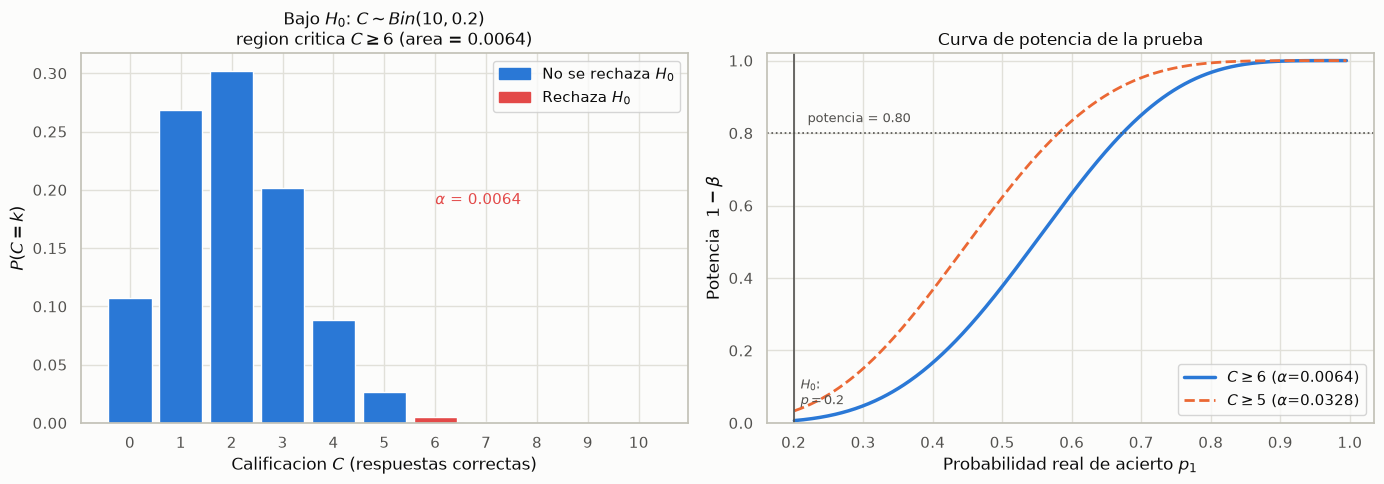

In [9]:
# Grafica: distribucion bajo H0 con la region critica resaltada + curva de potencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: pmf bajo H0 y region de rechazo
ax = axes[0]
k_plot = np.arange(0, n_preg + 1)
pmf_plot = st.binom.pmf(k_plot, n_preg, p_nulo)
colores = [COLOR_CRITICAL if k >= c_crit_pdf else PALETTE_CATEGORICAL[0]
           for k in k_plot]
ax.bar(k_plot, pmf_plot, color=colores, edgecolor="white", width=0.85)
ax.set_xlabel("Calificacion $C$ (respuestas correctas)")
ax.set_ylabel("$P(C = k)$")
ax.set_title(f"Bajo $H_0$: $C \\sim Bin({n_preg}, {p_nulo})$\n"
             f"region critica $C \\geq {c_crit_pdf}$ "
             f"(area = {alpha_real:.4f})")
ax.set_xticks(k_plot)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=PALETTE_CATEGORICAL[0],
                      label="No se rechaza $H_0$"),
        plt.Rectangle((0, 0), 1, 1, color=COLOR_CRITICAL,
                      label="Rechaza $H_0$"),
    ],
    loc="upper right",
)
ax.text(6.0, pmf_plot.max() * 0.62, f"$\\alpha$ = {alpha_real:.4f}",
        color=COLOR_CRITICAL, fontsize=11, ha="left")

# Panel derecho: curvas de potencia
ax = axes[1]
p_graf = np.linspace(0.201, 0.995, 500)
pot_graf = np.array([st.binom.sf(c_crit_pdf - 1, n_preg, p) for p in p_graf])
pot_graf5 = np.array([st.binom.sf(4, n_preg, p) for p in p_graf])
ax.plot(p_graf, pot_graf, color=PALETTE_CATEGORICAL[0], linewidth=2.5,
        label=f"$C \\geq {c_crit_pdf}$ ($\\alpha$={alpha_real:.4f})")
ax.plot(p_graf, pot_graf5, color=PALETTE_CATEGORICAL[1], linewidth=2,
        linestyle="--", label="$C \\geq 5$ ($\\alpha$=0.0328)")
ax.axhline(0.80, color=COLOR_NULO, linestyle=":", linewidth=1.2)
ax.text(0.22, 0.83, "potencia = 0.80", color=COLOR_NULO, fontsize=9)
ax.axvline(p_nulo, color=COLOR_NULO, linewidth=1.2)
ax.text(p_nulo + 0.01, 0.05, "$H_0$:\n$p=0.2$", color=COLOR_NULO, fontsize=9)
ax.set_xlabel("Probabilidad real de acierto $p_1$")
ax.set_ylabel("Potencia  $1 - \\beta$")
ax.set_title("Curva de potencia de la prueba")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

In [10]:
# p1 a partir del cual la potencia supera 0.80 (region C >= 6)
p_objetivo = 0.80
p_umbral = None
for p1 in np.arange(0.201, 0.999, 0.001):
    if st.binom.sf(c_crit_pdf - 1, n_preg, p1) >= p_objetivo:
        p_umbral = p1
        break
print(f"La potencia alcanza {p_objetivo:.2f} a partir de p1 ~ {p_umbral:.3f}")
print(f"(es decir, si el estudiante acierta ~{p_umbral*100:.1f} % de las preguntas,")
print(" la prueba lo detecta con 80 % de probabilidad)")

La potencia alcanza 0.80 a partir de p1 ~ 0.674
(es decir, si el estudiante acierta ~67.4 % de las preguntas,
 la prueba lo detecta con 80 % de probabilidad)


**Conclusión 5.7.** Bajo $H_0: p = 0.20$ la calificación sigue $C \sim \mathrm{Bin}(10, 0.20)$ y
la región crítica $C \geq 6$ tiene un nivel de significancia real

$$
\alpha = P(C \geq 6 \mid p = 0.20) = \sum_{k=6}^{10} \binom{10}{k} (0.2)^k (0.8)^{10-k}
\approx 0.006369,
$$

muy inferior al $0.05$ exigido, por lo que la prueba es **conservadora** (la región $C \geq 5$, con $\alpha \approx 0.0328$, sería la región más amplia admisible). El **error tipo II** es $\beta(p_1) = P(C \leq 5 \mid p_1)$ y la **potencia** es $1 - \beta(p_1)$: vale $\approx 0.377$ si el estudiante acierta la mitad de las preguntas ($p_1 = 0.5$) y $\approx 0.967$ si acierta el 80 %. La prueba sólo alcanza potencia $0.80$ cuando $p_1 \gtrsim 0.67$, de modo que **rechazar $H_0$ es concluyente (prueba de que el estudiante sabe), pero no rechazarla no prueba que el estudiante no sepa**: la prueba es asimétrica a favor de $H_1$.

[Volver al índice](#indice)

<a id="ej58"></a>
## 6. Ejemplo 5.8 — Prueba para la media de una población normal

Se sabe que las alturas de los individuos de una población se distribuyen como una
normal. Se desea contrastar, con un nivel de significancia $\alpha = 0.05$, si la altura
media **es diferente** de 174 cm. Con una muestra se obtuvieron los resultados:

$$
(174.03,\ 154.00,\ 170.53,\ 169.87,\ 157.48,\ 159.57,\ 175.17,\ 181.84,\ 178.45,\ 183.98,$$
$$
178.05,\ 165.18,\ 169.15,\ 169.41,\ 180.07,\ 159.07,\ 178.48,\ 165.03,\ 171.74,\ 161.60,$$
$$
161.79,\ 185.27,\ 162.00,\ 180.46,\ 159.10).
$$

Como la población es normal y **$\sigma$ es desconocida**, usamos la distribución $t$
de Student con $n - 1$ grados de libertad:

$$
H_0: \mu = 174 \quad\text{vs.}\quad H_1: \mu \neq 174,
\qquad
T = \frac{\bar X - \mu_0}{s/\sqrt{n}} \sim t_{n-1} \ \text{bajo } H_0.
$$

Es una prueba **bilateral**: como $H_1$ no indica dirección, la región de rechazo
tiene dos colas, cada una de área $\alpha/2$.

In [11]:
# Datos del Ejemplo 5.8
alturas = np.array([
    174.03, 154.00, 170.53, 169.87, 157.48, 159.57, 175.17, 181.84, 178.45,
    183.98, 178.05, 165.18, 169.15, 169.41, 180.07, 159.07, 178.48, 165.03,
    171.74, 161.60, 161.79, 185.27, 162.00, 180.46, 159.10,
])

n_e58 = len(alturas)
mu0_e58 = 174.0
alpha_e58 = 0.05
xbar_e58 = float(alturas.mean())
s2_e58 = float(alturas.var(ddof=1))
s_e58 = math.sqrt(s2_e58)
gl_e58 = n_e58 - 1
se_e58 = s_e58 / math.sqrt(n_e58)

print(f"n                 = {n_e58}")
print(f"media muestral    = {xbar_e58:.6f} cm")
print(f"s^2 (ddof=1)      = {s2_e58:.6f} cm^2")
print(f"s                 = {s_e58:.6f} cm")
print(f"error estandar    = s/sqrt(n) = {se_e58:.6f} cm")
print(f"gl = n - 1        = {gl_e58}")
print(f"min / max         = {alturas.min():.2f} / {alturas.max():.2f} cm")

n                 = 25
media muestral    = 170.052800 cm
s^2 (ddof=1)      = 85.197271 cm^2
s                 = 9.230237 cm
error estandar    = s/sqrt(n) = 1.846047 cm
gl = n - 1        = 24
min / max         = 154.00 / 185.27 cm


In [12]:
# Derivacion simbolica: el estadistico t y su relacion con el intervalo de confianza
n_s, xbar_s, mu0_s, s_s, t_s = sp.symbols("n xbar mu_0 s t", positive=True, real=True)
T_expr = (xbar_s - mu0_s) / (s_s / sp.sqrt(n_s))
margen_ic = t_s * s_s / sp.sqrt(n_s)
print("Estadistico de prueba (bajo H0, mu = mu_0):")
display(sp.Eq(sp.Symbol("T"), T_expr))
print("Despejando mu_0 el intervalo de confianza queda:")
display(sp.Eq(sp.Symbol("mu_0"), xbar_s - margen_ic))
print("Rechazar H0 (|T| > t_{alpha/2, n-1}) equivale a que mu_0 = 174 quede")
print("FUERA del intervalo de confianza: son la misma prueba dual.")

Estadistico de prueba (bajo H0, mu = mu_0):


    √n⋅(-μ₀ + x̅)
T = ────────────
         s      

Despejando mu_0 el intervalo de confianza queda:


         s⋅t
μ₀ = x̅ - ───
         √n 

Rechazar H0 (|T| > t_{alpha/2, n-1}) equivale a que mu_0 = 174 quede
FUERA del intervalo de confianza: son la misma prueba dual.


In [13]:
# Estadistico de prueba, region de rechazo, valor-p y decision
T_e58 = (xbar_e58 - mu0_e58) / se_e58
tcrit_e58 = float(st.t.ppf(1 - alpha_e58 / 2, gl_e58))
p_e58 = 2 * st.t.sf(abs(T_e58), gl_e58)

print(f"T = (xbar - mu0)/(s/sqrt(n)) = ({xbar_e58:.6f} - {mu0_e58})/{se_e58:.6f} = {T_e58:.6f}")
print(f"t_critico (alpha/2, gl={gl_e58}) = +/- {tcrit_e58:.6f}")
print(f"Region de rechazo: T < -{tcrit_e58:.4f}  o  T > {tcrit_e58:.4f}")
print(f"|T| = {abs(T_e58):.6f} {'>' if abs(T_e58) > tcrit_e58 else '<='} {tcrit_e58:.6f}"
      f"  -> {'rechaza' if abs(T_e58) > tcrit_e58 else 'no rechaza'} H0")
print()
decision(p_e58, alpha_e58, "mu = 174 cm", "mu != 174 cm")

T = (xbar - mu0)/(s/sqrt(n)) = (170.052800 - 174.0)/1.846047 = -2.138190
t_critico (alpha/2, gl=24) = +/- 2.063899
Region de rechazo: T < -2.0639  o  T > 2.0639
|T| = 2.138190 > 2.063899  -> rechaza H0

  H0            : mu = 174 cm
  H1            : mu != 174 cm
  alpha         : 0.05
  valor-p       : 0.042887
  Decision      : Rechazar H0
  Conclusion    : Se rechaza H0 (valor-p = 0.0429 <= alpha = 0.05)


'Se rechaza H0 (valor-p = 0.0429 <= alpha = 0.05)'

In [14]:
# Intervalo de confianza al 95% y su relacion con la prueba bilateral
margen_e58 = tcrit_e58 * se_e58
ic_e58 = (xbar_e58 - margen_e58, xbar_e58 + margen_e58)
print(f"IC 95% para mu = [{ic_e58[0]:.4f}, {ic_e58[1]:.4f}] cm")
print(f"i 174 esta fuera del IC? -> {not (ic_e58[0] <= mu0_e58 <= ic_e58[1])}")
print(f"  (equivale a rechazar H0 al 5 %)")
print(f"Distancia de xbar a mu0 = {abs(xbar_e58 - mu0_e58):.4f} cm "
      f"({abs(xbar_e58 - mu0_e58)/s_e58:.4f} desviaciones muestrales)")

IC 95% para mu = [166.2427, 173.8629] cm
i 174 esta fuera del IC? -> True
  (equivale a rechazar H0 al 5 %)
Distancia de xbar a mu0 = 3.9472 cm (0.4276 desviaciones muestrales)


In [15]:
# Verificacion con scipy.stats.ttest_1samp y con la variante unilateral
tt_scipy = st.ttest_1samp(alturas, mu0_e58)
print(f"ttest_1samp(alturas, 174)      : t = {tt_scipy.statistic:.6f}, p = {tt_scipy.pvalue:.6f}")
print(f"Nuestro calculo (bilateral)     : t = {T_e58:.6f}, p = {p_e58:.6f}")
p_uni = st.t.cdf(T_e58, gl_e58)   # cola inferior: muestra por DEBAJO de 174
print(f"p unilateral (cola inf., mu<174): {p_uni:.6f}  (la mitad del bilateral)")
print(f"d de Cohen (efecto)            : {(xbar_e58 - mu0_e58)/s_e58:.4f}")

ttest_1samp(alturas, 174)      : t = -2.138190, p = 0.042887
Nuestro calculo (bilateral)     : t = -2.138190, p = 0.042887
p unilateral (cola inf., mu<174): 0.021444  (la mitad del bilateral)
d de Cohen (efecto)            : -0.4276


In [16]:
# Robustez: si la normalidad fuera dudosa, prueba no parametrica de Wilcoxon
wil = st.wilcoxon(alturas - mu0_e58)
print(f"Wilcoxon (rangos con signo)     : W = {wil.statistic}, p = {wil.pvalue:.6f}")
print(f"Contraste: la prueba parametrica da p = {p_e58:.4f} (rechaza H0 al 5 %),")
print(f"mientras la no parametrica da p = {wil.pvalue:.4f} (no rechaza al 5 %,")
print("pero si al 10 %): la conclusion es sensible al supuesto de normalidad.")

Wilcoxon (rangos con signo)     : W = 92.0, p = 0.058752
Contraste: la prueba parametrica da p = 0.0429 (rechaza H0 al 5 %),
mientras la no parametrica da p = 0.0588 (no rechaza al 5 %,
pero si al 10 %): la conclusion es sensible al supuesto de normalidad.


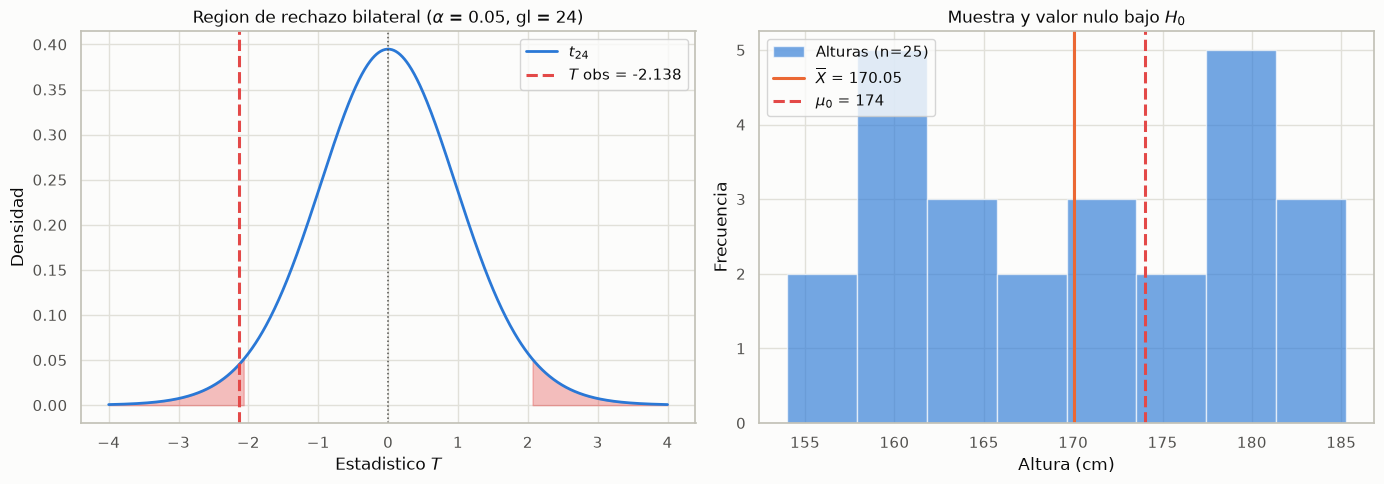

In [17]:
# Visualizacion: distribucion t bajo H0 con las dos colas de rechazo +
# distribucion muestral observada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: t de Student con region de rechazo bilateral
ax = axes[0]
x = np.linspace(-4, 4, 800)
pdf_t = st.t.pdf(x, gl_e58)
ax.plot(x, pdf_t, color=PALETTE_CATEGORICAL[0], linewidth=2,
        label=f"$t_{{{gl_e58}}}$")
ax.fill_between(x, pdf_t, where=(x <= -tcrit_e58), color=COLOR_CRITICAL, alpha=0.35)
ax.fill_between(x, pdf_t, where=(x >= tcrit_e58), color=COLOR_CRITICAL, alpha=0.35)
ax.axvline(T_e58, color=COLOR_HIGHLIGHT, linewidth=2.2, linestyle="--",
           label=f"$T$ obs = {T_e58:.3f}")
ax.axvline(0, color=COLOR_NULO, linewidth=1.1, linestyle=":")
ax.set_xlabel("Estadistico $T$")
ax.set_ylabel("Densidad")
ax.set_title(f"Region de rechazo bilateral ($\\alpha$ = {alpha_e58}, "
             f"gl = {gl_e58})")
ax.legend(loc="upper right")

# Panel derecho: histograma de la muestra con la media y mu0
ax = axes[1]
ax.hist(alturas, bins=8, color=PALETTE_CATEGORICAL[0], alpha=0.65,
        edgecolor="white", label=f"Alturas (n={n_e58})")
ax.axvline(xbar_e58, color=PALETTE_CATEGORICAL[1], linewidth=2.2,
           label=f"$\\overline{{X}}$ = {xbar_e58:.2f}")
ax.axvline(mu0_e58, color=COLOR_CRITICAL, linewidth=2.2, linestyle="--",
           label=f"$\\mu_0$ = {mu0_e58:.0f}")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Frecuencia")
ax.set_title("Muestra y valor nulo bajo $H_0$")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

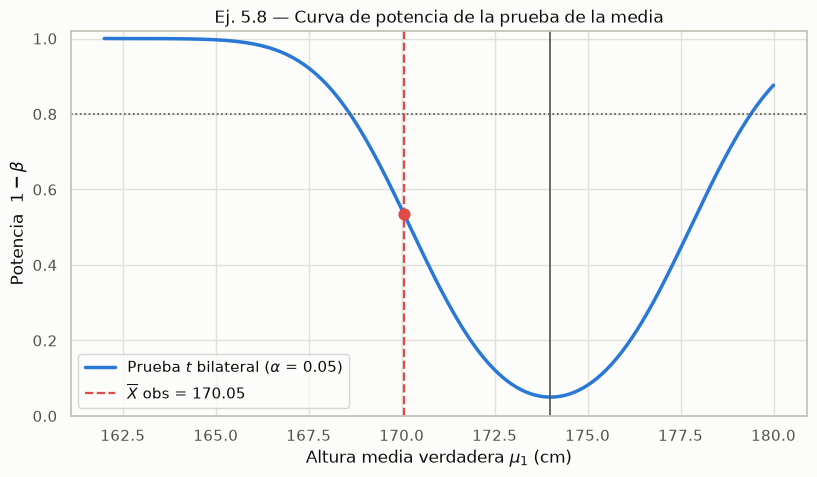

Con n = 25 y s = 9.230, la potencia alcanza 0.80 cuando
la media real se aleja de 174 hasta mu ~ 168.61 cm (desviacion ~5.39 cm).


In [18]:
# Curva de potencia: como crece la potencia si la media real se aleja de 174
mu_alt = np.linspace(162, 180, 300)
pot_e58 = np.array([
    st.nct.sf(tcrit_e58, gl_e58, (m - mu0_e58) / se_e58)
    + st.nct.cdf(-tcrit_e58, gl_e58, (m - mu0_e58) / se_e58)
    for m in mu_alt
])

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(mu_alt, pot_e58, color=PALETTE_CATEGORICAL[0], linewidth=2.5,
        label="Prueba $t$ bilateral ($\\alpha$ = 0.05)")
ax.axhline(0.80, color=COLOR_NULO, linestyle=":", linewidth=1.2)
ax.axvline(mu0_e58, color=COLOR_NULO, linewidth=1.2)
ax.axvline(xbar_e58, color=COLOR_HIGHLIGHT, linestyle="--", linewidth=1.6,
           label=f"$\\overline{{X}}$ obs = {xbar_e58:.2f}")
ax.scatter([xbar_e58], [pot_e58[np.argmin(np.abs(mu_alt - xbar_e58))]],
           color=COLOR_HIGHLIGHT, zorder=5, s=60)
ax.set_xlabel("Altura media verdadera $\\mu_1$ (cm)")
ax.set_ylabel("Potencia  $1 - \\beta$")
ax.set_title("Ej. 5.8 — Curva de potencia de la prueba de la media")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
plt.show()

#_mu que garantiza potencia 0.80 con esta muestra
mu_p80 = None
for m in np.arange(mu0_e58, 140, -0.001):
    pw = (st.nct.sf(tcrit_e58, gl_e58, (m - mu0_e58) / se_e58)
          + st.nct.cdf(-tcrit_e58, gl_e58, (m - mu0_e58) / se_e58))
    if pw >= 0.80:
        mu_p80 = m
        break
print(f"Con n = {n_e58} y s = {s_e58:.3f}, la potencia alcanza 0.80 cuando")
print(f"la media real se aleja de 174 hasta mu ~ {mu_p80:.2f} cm "
      f"(desviacion ~{abs(mu_p80-mu0_e58):.2f} cm).")

**Conclusión 5.8.** Con $n = 25$ se obtiene $\bar X = 170.0528$ cm y $s = 9.2302$ cm
($s^2 = 85.1973$). El estadístico de prueba es

$$
T = \frac{170.0528 - 174}{9.2302/\sqrt{25}} = \frac{-3.9472}{1.8460} = -2.1382,
$$

con $24$ grados de libertad y $|T| = 2.1382 > t_{0.025, 24} = 2.0639$, por lo que el
estadístico cae en la **región de rechazo bilateral** (valor-$p = 0.0429 \leq 0.05$).
Equivalentemente, el intervalo de confianza al 95 % para $\mu$ es
$(166.24,\ 173.86)$ cm, que **no contiene** el valor 174 cm. **Se rechaza $H_0$**: con
95 % de confianza hay evidencia de que la altura media de la población es
estadísticamente diferente de 174 cm (en la muestra observada, menor: $\approx 3.95$ cm
por debajo, un tamaño de efecto de $d \approx -0.43$). La robustez es moderada: la
prueba de Wilcoxon da $p = 0.0588$ y no rechazaría al 5 %.

[Volver al índice](#indice)

<a id="ej59"></a>
## 7. Ejemplo 5.9 — Prueba para la varianza de una población normal

Una empresa de transporte aéreo para ejecutivos busca proyectar una imagen de
confiabilidad garantizando la puntualidad de sus conductores en la terminal de llegada;
su objetivo es **minimizar la variabilidad** de los tiempos de llegada y para ello ha
implementado una estrategia con la que pretende lograr que la varianza sea **igual o
inferior a 4 minutos**. Se tomó una muestra aleatoria de $n = 24$ llegadas, la varianza
muestral es $s^2 = 4.9$ y se supone que los tiempos siguen una distribución normal. Con
un nivel de significancia del 5 % se analizará si la empresa ha logrado su objetivo.

Como la población es normal y el parámetro de interés es la varianza, usamos el
estadístico chi-cuadrado:

$$
H_0: \sigma^2 \leq 4 \quad\text{vs.}\quad H_1: \sigma^2 > 4,
\qquad
X^2 = \frac{(n-1) S^2}{\sigma_0^2} \sim \chi^2_{n-1} \ \text{bajo } H_0.
$$

Es una prueba **unilateral a la derecha**: la alternativa postula una varianza *mayor*
que el objetivo, de modo que la región de rechazo es la cola superior, con
$X^2 > \chi^2_{\alpha, n-1}$. Nótese que la hipótesis nula incluye el valor en el
frontero $\sigma^2 = 4$, que es el que se usa para calibrar el nivel de significancia.

In [19]:
# Parametros del Ejemplo 5.9
n_e59 = 24
s2_e59 = 4.9                # varianza muestral observada
sigma2_0 = 4.0              # varianza objetivo (minuto^2)
alpha_e59 = 0.05
gl_e59 = n_e59 - 1

print(f"n                      = {n_e59}")
print(f"s^2 muestral           = {s2_e59} min^2")
print(f"s muestral             = {math.sqrt(s2_e59):.6f} min")
print(f"sigma^2 objetivo (H0)  = {sigma2_0} min^2")
print(f"alpha                  = {alpha_e59}")
print(f"gl = n - 1             = {gl_e59}")

n                      = 24
s^2 muestral           = 4.9 min^2
s muestral             = 2.213594 min
sigma^2 objetivo (H0)  = 4.0 min^2
alpha                  = 0.05
gl = n - 1             = 23


In [20]:
# Derivacion simbolica: por que (n-1)S^2 / sigma_0^2 ~ chi^2_{n-1}
n_s, sigma2_s, s2_s = sp.symbols("n sigma^2 s^2", positive=True, real=True)
X2 = ((n_s - 1) * s2_s) / sigma2_s
print("Estadistico de prueba (con sigma_0^2 en el denominador):")
display(sp.Eq(sp.Symbol("X^2"), X2))
print("Bajo H0, la suma de (n-1) normalizacion por su varianza sigue chi^2_{n-1}.")
x2crit_cola = float(st.chi2.ppf(1 - alpha_e59, gl_e59))
print("Region de rechazo unilateral (cola derecha): X^2 > "
      f"chi^2_{{1-alpha, n-1}} = {x2crit_cola:.4f}")

Estadistico de prueba (con sigma_0^2 en el denominador):


     s²⋅(n - 1)
X² = ──────────
         σ²    

Bajo H0, la suma de (n-1) normalizacion por su varianza sigue chi^2_{n-1}.
Region de rechazo unilateral (cola derecha): X^2 > chi^2_{1-alpha, n-1} = 35.1725


In [21]:
# Estadistico, region de rechazo, valor-p y decision
X2_e59 = (gl_e59 * s2_e59) / sigma2_0
x2crit_e59 = float(st.chi2.ppf(1 - alpha_e59, gl_e59))
p_e59 = float(st.chi2.sf(X2_e59, gl_e59))

print(f"X^2 = (n-1)s^2/sigma_0^2 = {gl_e59}*{s2_e59}/{sigma2_0} = {X2_e59:.6f}")
print(f"x^2 critico (cola derecha, alpha={alpha_e59}, gl={gl_e59}) = {x2crit_e59:.6f}")
print(f"Region de rechazo: X^2 > {x2crit_e59:.4f}")
print(f"X^2 obs = {X2_e59:.4f} {'>' if X2_e59 > x2crit_e59 else '<='} "
      f"{x2crit_e59:.4f} -> {'rechaza' if X2_e59 > x2crit_e59 else 'no rechaza'} H0")
print()
decision(p_e59, alpha_e59, "sigma^2 <= 4 min^2", "sigma^2 > 4 min^2")

X^2 = (n-1)s^2/sigma_0^2 = 23*4.9/4.0 = 28.175000
x^2 critico (cola derecha, alpha=0.05, gl=23) = 35.172462
Region de rechazo: X^2 > 35.1725
X^2 obs = 28.1750 <= 35.1725 -> no rechaza H0

  H0            : sigma^2 <= 4 min^2
  H1            : sigma^2 > 4 min^2
  alpha         : 0.05
  valor-p       : 0.209236
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.2092 > alpha = 0.05)


'No se rechaza H0 (valor-p = 0.2092 > alpha = 0.05)'

In [22]:
# Contraste con la version bilateral y con el intervalo de confianza para sigma^2
x2crit_inf = float(st.chi2.ppf(alpha_e59 / 2, gl_e59))
x2crit_sup = float(st.chi2.ppf(1 - alpha_e59 / 2, gl_e59))
p_bilat = 2 * min(st.chi2.cdf(X2_e59, gl_e59), st.chi2.sf(X2_e59, gl_e59))
print(f"Version bilateral: criticos = [{x2crit_inf:.4f}, {x2crit_sup:.4f}], "
      f"valor-p = {p_bilat:.4f}")
print(f"  {X2_e59:.4f} esta dentro de [{x2crit_inf:.4f}, {x2crit_sup:.4f}]? -> "
      f"{x2crit_inf <= X2_e59 <= x2crit_sup}  (tambien se falla en rechazar H0)")

ic_var = (gl_e59 * s2_e59 / x2crit_sup, gl_e59 * s2_e59 / x2crit_inf)
print(f"\nIC 95% para sigma^2 = [{ic_var[0]:.4f}, {ic_var[1]:.4f}] min^2")
print(f"  (sigma esta entre {math.sqrt(ic_var[0]):.3f} y {math.sqrt(ic_var[1]):.3f} min)")
print(f"  i 4 esta dentro del IC? -> {ic_var[0] <= sigma2_0 <= ic_var[1]}")
print("  Ojo: el IC incluye valores de varianza MUY por encima de 4, de modo que")
print("  los datos no confirman que sigma^2 <= 4; solo son compatibles con ello.")

Version bilateral: criticos = [11.6886, 38.0756], valor-p = 0.4185
  28.1750 esta dentro de [11.6886, 38.0756]? -> True  (tambien se falla en rechazar H0)

IC 95% para sigma^2 = [2.9599, 9.6419] min^2
  (sigma esta entre 1.720 y 3.105 min)
  i 4 esta dentro del IC? -> True
  Ojo: el IC incluye valores de varianza MUY por encima de 4, de modo que
  los datos no confirman que sigma^2 <= 4; solo son compatibles con ello.


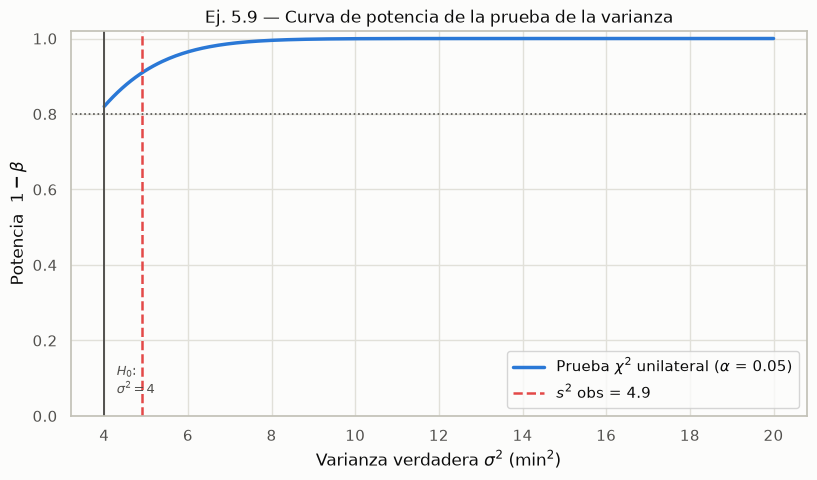

Potencia en la frontera sigma^2 = 4.0: 0.8202
Potencia en el valor observado  s^2 = 4.9: 0.9089

Tabla de potencia:
  sigma^2   potencia
      4.0     0.8202
      4.9     0.9089
      6.0     0.9647
      8.0     0.9952
     10.0     0.9995
     16.0     1.0000


In [23]:
# Analisis de potencia: con que frecuencia se detectaria una varianza mayor
sigma2_alt = np.linspace(4, 20, 300)
pot_e59 = np.array([st.ncx2.sf(x2crit_e59, gl_e59, gl_e59 * s / sigma2_0)
                    for s in sigma2_alt])

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(sigma2_alt, pot_e59, color=PALETTE_CATEGORICAL[0], linewidth=2.5,
        label=f"Prueba $\\chi^2$ unilateral ($\\alpha$ = {alpha_e59})")
ax.axhline(0.80, color=COLOR_NULO, linestyle=":", linewidth=1.2)
ax.axvline(sigma2_0, color=COLOR_NULO, linewidth=1.4)
ax.text(sigma2_0 + 0.3, 0.06, "$H_0$:\n$\\sigma^2 = 4$", color=COLOR_NULO,
        fontsize=9)
ax.axvline(s2_e59, color=COLOR_HIGHLIGHT, linestyle="--", linewidth=1.8,
           label=f"$s^2$ obs = {s2_e59}")
ax.set_xlabel("Varianza verdadera $\\sigma^2$ (min$^2$)")
ax.set_ylabel("Potencia  $1 - \\beta$")
ax.set_title("Ej. 5.9 — Curva de potencia de la prueba de la varianza")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
plt.show()

pot_frontera = st.ncx2.sf(x2crit_e59, gl_e59, gl_e59 * sigma2_0 / sigma2_0)
print(f"Potencia en la frontera sigma^2 = {sigma2_0}: {pot_frontera:.4f}")
print(f"Potencia en el valor observado  s^2 = {s2_e59}: "
      f"{st.ncx2.sf(x2crit_e59, gl_e59, gl_e59*s2_e59/sigma2_0):.4f}")
print("\nTabla de potencia:")
print(f"{'sigma^2':>9} {'potencia':>10}")
for s2 in [4.0, 4.9, 6.0, 8.0, 10.0, 16.0]:
    print(f"{s2:>9.1f} {st.ncx2.sf(x2crit_e59, gl_e59, gl_e59*s2/sigma2_0):>10.4f}")

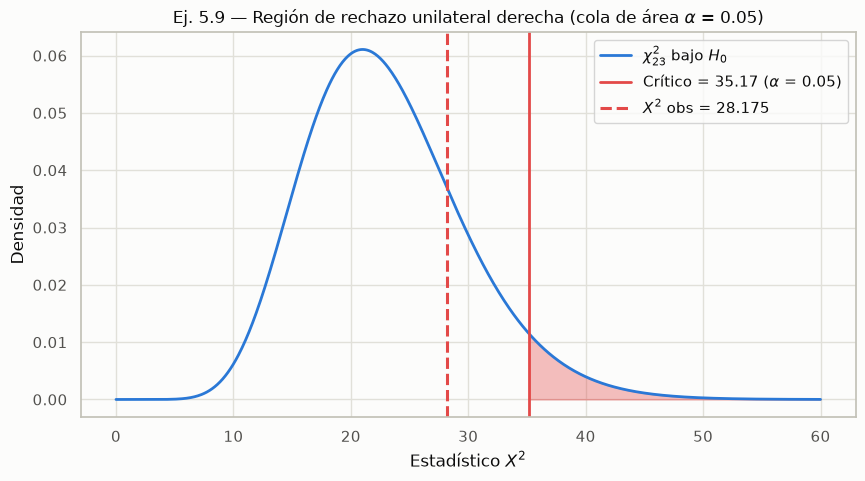

In [24]:
# Visualizacion: distribucion chi-cuadrado con la region de rechazo
fig, ax = plt.subplots(figsize=(10, 5))
x_chi = np.linspace(0, 60, 800)
pdf_chi = st.chi2.pdf(x_chi, gl_e59)
ax.plot(x_chi, pdf_chi, color=PALETTE_CATEGORICAL[0], linewidth=2,
        label=f"$\\chi^2_{{{gl_e59}}}$ bajo $H_0$")
ax.fill_between(x_chi, pdf_chi, where=(x_chi >= x2crit_e59),
                color=COLOR_CRITICAL, alpha=0.35)
ax.axvline(x2crit_e59, color=COLOR_CRITICAL, linewidth=2,
           label=f"Crítico = {x2crit_e59:.2f} ($\\alpha$ = 0.05)")
ax.axvline(X2_e59, color=COLOR_HIGHLIGHT, linestyle="--", linewidth=2.2,
           label=f"$X^2$ obs = {X2_e59:.3f}")
ax.set_xlabel("Estadístico $X^2$")
ax.set_ylabel("Densidad")
ax.set_title("Ej. 5.9 — Región de rechazo unilateral derecha "
             "(cola de área $\\alpha$ = 0.05)")
ax.legend(loc="upper right")
plt.show()

**Conclusión 5.9.** El estadístico chi-cuadrado es

$$
X^2 = \frac{(24-1)(4.9)}{4} = 28.175,
$$

y el valor crítico en la cola derecha al 5 % con $23$ grados de libertad es
$\chi^2_{0.05,\,23} = 35.172$. Como $28.175 < 35.172$, el estadístico **no cae en la
región de rechazo** (valor-$p = 0.2092$). **No se rechaza $H_0$**: al 5 % no hay
evidencia estadísticamente significativa de que la varianza de los tiempos de llegada
supere los 4 minutos, por lo que la estrategia de la empresa es **compatible** con el
objetivo de confiabilidad.

Sin embargo, la conclusión debe leerse con cuidado en ambos sentidos: (i) el intervalo
de confianza al 95 % para $\sigma^2$ es $(2.96,\ 9.64)$ min$^2$, que incluye valores
muy por encima de 4, de modo que los datos **no prueban** que $\sigma^2 \leq 4$ — sólo
que el objetivo es plausible; y (ii) si lo que se quisiera demostrar fuera que la
empresa **cumplió** su meta, la decisión statisticamente correcta es no rechazar
$H_0$, porque el objetivo está enunciado como hipótesis nula. La prueba tiene
potencia $\approx 0.82$ en la frontera $\sigma^2 = 4$ y $\approx 0.99$ para
$\sigma^2 \geq 8$.

[Volver al índice](#indice)

<a id="ej510"></a>
## 8. Ejemplo 5.10 — Prueba para dos poblaciones normales

Para determinar si un nuevo suero tiene efectos en la detención de la leucemia se
eligen **9 ratones**, todos en etapa avanzada de la enfermedad: **5 ratones** reciben el
tratamiento con el nuevo suero y los **4 restantes** no reciben tratamiento. Los tiempos
de supervivencia (en años) desde el inicio del experimento son:

| Con tratamiento | 2.1 | 5.3 | 1.4 | 4.6 | 0.9 |
|---|---|---|---|---|---|
| **Sin tratamiento** | 1.9 | 0.5 | 2.8 | 3.1 | — |

Se quiere saber si, con un nivel de significancia $\alpha = 0.05$, se puede afirmar que
el suero es efectivo, bajo la premisa de que **ambas poblaciones se distribuyen
normalmente y tienen varianzas iguales**.

Como se supone $\sigma_1^2 = \sigma_2^2 = \sigma^2$, usamos la prueba $t$ de dos
muestras con varianza agrupada (*pooled*), y como la Effectiveness del suero implica una
mayor supervivencia, la alternativa es unilateral a la derecha:

$$
H_0: \mu_1 = \mu_2 \quad\text{vs.}\quad H_1: \mu_1 > \mu_2,
$$

$$
T = \frac{\bar X_1 - \bar X_2}{S_p\sqrt{1/n_1 + 1/n_2}} \sim t_{n_1+n_2-2} \ \text{bajo } H_0,
\qquad
S_p^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1 + n_2 - 2}.
$$

In [25]:
# Datos del Ejemplo 5.10
con_suero = np.array([2.1, 5.3, 1.4, 4.6, 0.9])
sin_suero = np.array([1.9, 0.5, 2.8, 3.1])

n1_e510, n2_e510 = len(con_suero), len(sin_suero)
m1_e510, m2_e510 = float(con_suero.mean()), float(sin_suero.mean())
v1_e510, v2_e510 = float(con_suero.var(ddof=1)), float(sin_suero.var(ddof=1))
gl_e510 = n1_e510 + n2_e510 - 2
alpha_e510 = 0.05

print(f"Con suero  : n1 = {n1_e510}, m1 = {m1_e510:.6f}, s1^2 = {v1_e510:.6f}, "
      f"s1 = {math.sqrt(v1_e510):.6f}")
print(f"Sin suero  : n2 = {n2_e510}, m2 = {m2_e510:.6f}, s2^2 = {v2_e510:.6f}, "
      f"s2 = {math.sqrt(v2_e510):.6f}")
print(f"Diferencia de medias = {m1_e510 - m2_e510:.6f} anos")
print(f"gl = n1 + n2 - 2 = {gl_e510}")

Con suero  : n1 = 5, m1 = 2.860000, s1^2 = 3.883000, s1 = 1.970533
Sin suero  : n2 = 4, m2 = 2.075000, s2^2 = 1.362500, s2 = 1.167262
Diferencia de medias = 0.785000 anos
gl = n1 + n2 - 2 = 7


In [26]:
# Verificacion del supuesto de varianzas iguales con la prueba F y Levene
F_obs = v1_e510 / v2_e510
p_F = 2 * min(st.f.cdf(F_obs, n1_e510 - 1, n2_e510 - 1),
              st.f.sf(F_obs, n1_e510 - 1, n2_e510 - 1))
lev = st.levene(con_suero, sin_suero)
print(f"Prueba F de igualdad de varianzas: F = {F_obs:.6f}, "
      f"(gl1, gl2) = ({n1_e510-1}, {n2_e510-1}), p = {p_F:.4f}")
print(f"Prueba de Levene                 : W = {lev.statistic:.6f}, p = {lev.pvalue:.4f}")
print(f"i las varianzas son iguales?     -> {p_F > alpha_e510} "
      f"(no se rechazan la igualdad: supuesto admisible)")

Prueba F de igualdad de varianzas: F = 2.849908, (gl1, gl2) = (4, 3), p = 0.4160
Prueba de Levene                 : W = 0.789641, p = 0.4037
i las varianzas son iguales?     -> True (no se rechazan la igualdad: supuesto admisible)


In [27]:
# Derivacion simbolica: varianza agrupada y estadistico de la prueba
n1s, n2s, v1s, v2s, x1s, x2s = sp.symbols("n1 n2 s1^2 s2^2 x1 x2", positive=True, real=True)
sp2 = ((n1s - 1) * v1s + (n2s - 1) * v2s) / (n1s + n2s - 2)
T_pooled = (x1s - x2s) / (sp.sqrt(sp2) * sp.sqrt(1 / n1s + 1 / n2s))
print("Varianza agrupada (pooled):")
display(sp.Eq(sp.Symbol("s_p^2"), sp2))
print("Estadistico de prueba con varianzas iguales:")
display(sp.Eq(sp.Symbol("T"), T_pooled))
print("gl = n1 + n2 - 2 =", gl_e510)

Varianza agrupada (pooled):


      s²₁⋅(n₁ - 1) + s²₂⋅(n₂ - 1)
s²ₚ = ───────────────────────────
              n₁ + n₂ - 2        

Estadistico de prueba con varianzas iguales:


                        x₁ - x₂                    
T = ───────────────────────────────────────────────
        _____________________________     _________
       ╱ s²₁⋅(n₁ - 1) + s²₂⋅(n₂ - 1)     ╱ 1    1  
      ╱  ─────────────────────────── ⋅  ╱  ── + ── 
    ╲╱           n₁ + n₂ - 2          ╲╱   n₂   n₁ 

gl = n1 + n2 - 2 = 7


In [28]:
# Calculo de la prueba t agrupada
sp2_e510 = ((n1_e510 - 1) * v1_e510 + (n2_e510 - 1) * v2_e510) / gl_e510
sp_e510 = math.sqrt(sp2_e510)
se_e510 = sp_e510 * math.sqrt(1 / n1_e510 + 1 / n2_e510)
T_e510 = (m1_e510 - m2_e510) / se_e510
tcrit_uni = float(st.t.ppf(1 - alpha_e510, gl_e510))
tcrit_bi = float(st.t.ppf(1 - alpha_e510 / 2, gl_e510))
p_uni_510 = float(st.t.sf(T_e510, gl_e510))
p_bi_510 = float(2 * st.t.sf(abs(T_e510), gl_e510))

print(f"s_p^2 (agrupada)  = {sp2_e510:.6f}")
print(f"s_p               = {sp_e510:.6f}")
print(f"Error estandar de la diferencia = {se_e510:.6f}")
print(f"T = ({m1_e510:.4f} - {m2_e510:.4f})/{se_e510:.6f} = {T_e510:.6f}")
print(f"t critico unilateral (alpha={alpha_e510}) = {tcrit_uni:.6f}")
print(f"t critico bilateral  (alpha/2)           = {tcrit_bi:.6f}")
print(f"Region de rechazo: T > {tcrit_uni:.4f}")
print(f"T obs = {T_e510:.4f} {'>' if T_e510 > tcrit_uni else '<='} {tcrit_uni:.4f} "
      f"-> {'rechaza' if T_e510 > tcrit_uni else 'no rechaza'} H0")
print()
decision(p_uni_510, alpha_e510, "mu_1 = mu_2 (sin efecto del suero)",
         "mu_1 > mu_2 (el suero extiende la supervivencia)")

s_p^2 (agrupada)  = 2.802786
s_p               = 1.674152
Error estandar de la diferencia = 1.123055
T = (2.8600 - 2.0750)/1.123055 = 0.698986
t critico unilateral (alpha=0.05) = 1.894579
t critico bilateral  (alpha/2)           = 2.364624
Region de rechazo: T > 1.8946
T obs = 0.6990 <= 1.8946 -> no rechaza H0

  H0            : mu_1 = mu_2 (sin efecto del suero)
  H1            : mu_1 > mu_2 (el suero extiende la supervivencia)
  alpha         : 0.05
  valor-p       : 0.253557
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.2536 > alpha = 0.05)


'No se rechaza H0 (valor-p = 0.2536 > alpha = 0.05)'

In [29]:
# Contraste con la version bilateral y con el intervalo de confianza
margen_510 = tcrit_bi * se_e510
ic_510 = ((m1_e510 - m2_e510) - margen_510, (m1_e510 - m2_e510) + margen_510)
tt_welch = st.ttest_ind(con_suero, sin_suero, equal_var=True)
print(f"ttest_ind(equal_var=True): t = {tt_welch.statistic:.6f}, p = {tt_welch.pvalue:.6f}")
print(f"Nuestro calculo bilateral  : t = {T_e510:.6f}, p = {p_bi_510:.6f}")
print(f"\nIC 95% para mu_1 - mu_2 = ({ic_510[0]:.4f}, {ic_510[1]:.4f}) anos")
print(f"  i 0 esta dentro del IC? -> {ic_510[0] <= 0 <= ic_510[1]} "
      f"(imposible afirmar que el suero prolonga la vida)")
print(f"Margen de error (95 %)   = +/- {margen_510:.4f} anos, es enorme frente a")
print(f"  la diferencia observada de {m1_e510 - m2_e510:.4f} anos: la muestra es muy pequena.")

ttest_ind(equal_var=True): t = 0.698986, p = 0.507113
Nuestro calculo bilateral  : t = 0.698986, p = 0.507113

IC 95% para mu_1 - mu_2 = (-1.8706, 3.4406) anos
  i 0 esta dentro del IC? -> True (imposible afirmar que el suero prolonga la vida)
Margen de error (95 %)   = +/- 2.6556 anos, es enorme frente a
  la diferencia observada de 0.7850 anos: la muestra es muy pequena.


In [30]:
# Prueba no parametrica de Mann-Whitney como contraste de robustez
mw = st.mannwhitneyu(con_suero, sin_suero, alternative="greater")
print(f"Mann-Whitney U (cola >)   : U = {mw.statistic}, p = {mw.pvalue:.6f}")
print(f"Prueba t agrupada (cola >): t = {T_e510:.4f}, p = {p_uni_510:.4f}")
print("Ambas pruebas coinciden: no hay evidencia de efecto del suero.")

Mann-Whitney U (cola >)   : U = 12.0, p = 0.365079
Prueba t agrupada (cola >): t = 0.6990, p = 0.2536
Ambas pruebas coinciden: no hay evidencia de efecto del suero.


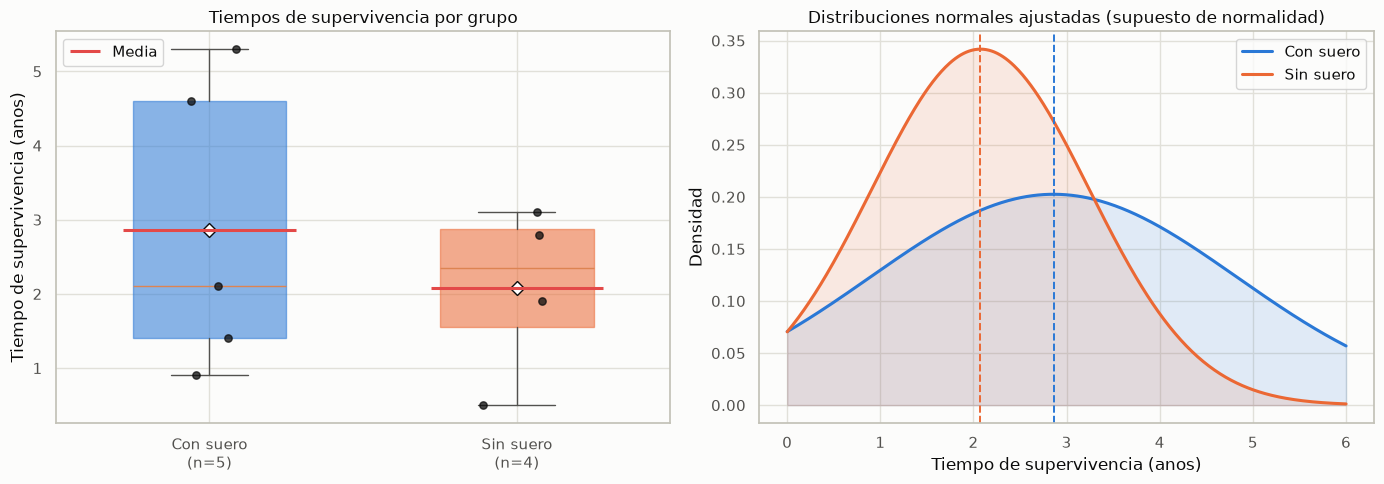

In [31]:
# Visualizacion: distribuciones de supervivencia + curva de potencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: boxplots y puntos
ax = axes[0]
datos_510 = [con_suero, sin_suero]
bp = ax.boxplot(datos_510, tick_labels=["Con suero\n(n=5)", "Sin suero\n(n=4)"],
                patch_artist=True, widths=0.5, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "#0b0b0b", "markersize": 7})
for patch, color in zip(bp["boxes"], [COLOR_TRAT, COLOR_CTRL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
    patch.set_edgecolor(color)
for key in ("whiskers", "caps"):
    for item in bp[key]:
        item.set_color("#52514e")
rng = np.random.default_rng(7)
for i, (d, m) in enumerate(zip(datos_510, [m1_e510, m2_e510]), start=1):
    x_jit = i + rng.uniform(-0.11, 0.11, size=len(d))
    ax.scatter(x_jit, d, color="#0b0b0b", zorder=3, s=28, alpha=0.75)
    ax.hlines(m, i - 0.28, i + 0.28, color=COLOR_HIGHLIGHT, linewidth=2.2,
              zorder=4, label="Media" if i == 1 else None)
ax.set_ylabel("Tiempo de supervivencia (anos)")
ax.set_title("Tiempos de supervivencia por grupo")
ax.legend(loc="upper left")

# Panel derecho: distribuciones normales superpuestas
ax = axes[1]
x_510 = np.linspace(0, 6, 400)
for d, m, s, color, lab in [
    (con_suero, m1_e510, math.sqrt(v1_e510), COLOR_TRAT, "Con suero"),
    (sin_suero, m2_e510, math.sqrt(v2_e510), COLOR_CTRL, "Sin suero"),
]:
    ax.plot(x_510, st.norm.pdf(x_510, m, s), color=color, linewidth=2.2, label=lab)
    ax.fill_between(x_510, 0, st.norm.pdf(x_510, m, s), color=color, alpha=0.13)
ax.axvline(m1_e510, color=COLOR_TRAT, linestyle="--", linewidth=1.4)
ax.axvline(m2_e510, color=COLOR_CTRL, linestyle="--", linewidth=1.4)
ax.set_xlabel("Tiempo de supervivencia (anos)")
ax.set_ylabel("Densidad")
ax.set_title("Distribuciones normales ajustadas "
             "(supuesto de normalidad)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

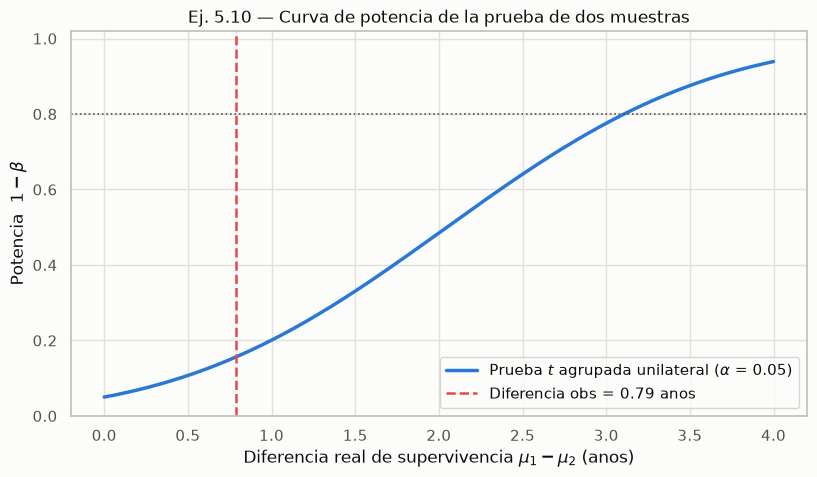

  delta real   potencia
         0.0     0.0500
         0.5     0.1073
         1.0     0.2008
         1.5     0.3308
         2.0     0.4848
         3.0     0.7754

Para alcanzar potencia 0.80 con n1=5, n2=4 haria falta una diferencia
real de al menos 3.11 anos de supervivencia, cuando la observada
es de 0.79 anos: el estudio esta mal dimensionado (subdimensionado).


In [32]:
# Curva de potencia: que diferencia real habria que observar para tener potencia 0.80
delta_alt = np.linspace(0, 4, 300)
pot_510 = np.array([st.nct.sf(tcrit_uni, gl_e510, d / se_e510) for d in delta_alt])

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(delta_alt, pot_510, color=PALETTE_CATEGORICAL[0], linewidth=2.5,
        label=f"Prueba $t$ agrupada unilateral ($\\alpha$ = {alpha_e510})")
ax.axhline(0.80, color=COLOR_NULO, linestyle=":", linewidth=1.2)
ax.axvline(m1_e510 - m2_e510, color=COLOR_HIGHLIGHT, linestyle="--", linewidth=1.8,
           label=f"Diferencia obs = {m1_e510 - m2_e510:.2f} anos")
ax.set_xlabel("Diferencia real de supervivencia $\\mu_1 - \\mu_2$ (anos)")
ax.set_ylabel("Potencia  $1 - \\beta$")
ax.set_title("Ej. 5.10 — Curva de potencia de la prueba de dos muestras")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
plt.show()

print(f"{'delta real':>12} {'potencia':>10}")
for d in [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]:
    print(f"{d:>12.1f} {st.nct.sf(tcrit_uni, gl_e510, d/se_e510):>10.4f}")

# delta requerido para potencia 0.80 con estos 9 ratones
delta_p80 = None
for d in np.arange(0, 10, 0.001):
    if st.nct.sf(tcrit_uni, gl_e510, d / se_e510) >= 0.80:
        delta_p80 = d
        break
print(f"\nPara alcanzar potencia 0.80 con n1=5, n2=4 haria falta una diferencia")
print(f"real de al menos {delta_p80:.2f} anos de supervivencia, cuando la observada")
print(f"es de {m1_e510 - m2_e510:.2f} anos: el estudio esta mal dimensionado (subdimensionado).")

<a id="resumen"></a>
## 9. Resumen comparativo

Los cuatro ejemplos, ordenados por parámetro y tipo de problema:

| # | Parámetro | $H_0$ | $H_1$ | Estadística | Distribución bajo $H_0$ | gl | Estadístico | Crítico | valor-$p$ | $\alpha$ | Decisión |
|---|-----------|-------|-------|-------------|--------------------------|----|-------------|----------|-----------|-------|----------|
| 5.7 | $p$ (proporción) | $p = 0.20$ | $p > 0.20$ | $C$ (aciertos) | $\mathrm{Bin}(10, 0.2)$ | — | $C \geq 6$ | — | $\approx 0.0064$ | 0.05 | Rechaza $H_0$ si $C \geq 6$ |
| 5.8 | $\mu$ (media) | $\mu = 174$ | $\mu \neq 174$ | $T$ | $t_{24}$ | 24 | $-2.1382$ | $\pm 2.0639$ | 0.0429 | 0.05 | **Rechaza $H_0$** |
| 5.9 | $\sigma^2$ (varianza) | $\sigma^2 \leq 4$ | $\sigma^2 > 4$ | $X^2$ | $\chi^2_{23}$ | 23 | 28.175 | 35.172 | 0.2092 | 0.05 | **No rechaza $H_0$** |
| 5.10 | $\mu_1 - \mu_2$ | $\mu_1 = \mu_2$ | $\mu_1 > \mu_2$ | $T$ (agrupada) | $t_7$ | 7 | 0.6990 | 1.8946 | 0.2536 | 0.05 | **No rechaza $H_0$** |

**Interpretación de las decisiones.** Sólo el Ejemplo 5.8 produce evidencia
estadísticamente significativa: la altura media poblacional difiere de 174 cm. En el
Ejemplo 5.9 el objetivo de la empresa (varianza $\leq 4$) es el enunciado como $H_0$, de
modo que no rechazarla es consistente con el cumplimiento del objetivo, aunque el
intervalo de confianza $(\approx 3,\ \approx 10)$ min$^2$ muestra que los datos no
acotan la varianza por arriba de forma útil. En el Ejemplo 5.10 la diferencia observada
$(0.785$ años) es demasiado pequeña frente a la variabilidad de la muestra para
detectarse con sólo 9 ratones.

**Sobre el valor-$p$.** Un valor-$p$ no es la probabilidad de que $H_0$ sea cierta, sino
$P(\text{observar datos al menos tan extremos} \mid H_0)$. Por eso en 5.8 y 5.9 y 5.10 se
informa siempre junto con el tamaño del efecto y su intervalo de confianza, que es lo
que da significado práctico a la decisión.

<a id="conclusiones"></a>
## 10. Conclusiones

Los cuatro ejemplos recorren las familias de pruebas de hipótesis clásicas y permiten
extender varias ideas generales.

**Puntos a recordar:**

1. **La hipótesis nula es la de «no efecto»** (no saber, $\mu = \mu_0$, $\sigma^2 \leq \sigma_0^2$, $\mu_1 = \mu_2$) y la alternativa la que postula el efecto. Elegir la alternativa fija la dirección de la prueba.
2. **La región crítica se calibra bajo $H_0$** para que el área sea $\alpha$. En el Ejemplo 5.7 la región $C \geq 6$ da un $\alpha$ real de $0.0064$, muy por debajo del $0.05$ nominal: la prueba es conservadora y su potencia es baja ($\approx 0.38$ si $p = 0.5$).
3. **No rechazar $H_0$ no es probarla.** En 5.9 y 5.10 el resultado no es «la varianza es 4» ni «el suero no funciona», sino «los datos no permiten detectar un efecto de este tamaño con estas muestras».
4. **El valor-$p$ depende del tamaño de muestra y del error estándar.** Con 9 ratones (Ej. 5.10) harían falta diferencias reales de $\approx 3.1$ años para alcanzar potencia $0.80$; la diferencia observada de $0.785$ años queda muy lejos.
5. **Los supuestos importan.** En 5.8 la normalidad es necesaria para la prueba $t$ (Wilcoxon da $p = 0.0588$); en 5.9 y 5.10 es indispensable para usar $\chi^2$ y $t$ agrupada; en 5.10 además se supone igualdad de varianzas (verificada aquí con la prueba $F$, $p = 0.416$).
6. **Una decisión estadística se acompaña siempre de su intervalo de confianza**, que es la misma prueba reescrita: el IC al 95 % de 5.8 $(166.24, 173.86)$ no contiene 174 cm; el de 5.9 $(2.96, 9.64)$ no permite afirmar $\sigma^2 \leq 4$; el de 5.10 $(-1.87, 3.44)$ contiene 0.
7. **La potencia es parte del análisis.** Las curvas de potencia muestran qué tamaño de efecto es realmente detectable con cada diseño, y son la guía para planificar estudios con muestras suficientes.

[Volver al índice](#indice)